In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.ar_model import AutoReg

In [2]:
def _flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    yfinance sometimes returns MultiIndex columns like ('Close','XLK').
    This makes a clean single-level set of columns: Close, High, Low, Open, Volume, Adj Close (if exists).
    """
    if isinstance(df.columns, pd.MultiIndex):
        # Keep the first level (e.g., 'Close', 'Open', ...)
        df = df.copy()
        df.columns = [c[0] for c in df.columns]
    return df

In [3]:
def build_liquidity_df(
    ticker: str,
    start: str = "1999-12-03",
    auto_adjust: bool = True,
) -> pd.DataFrame:
    """
    Downloads OHLCV and builds your liquidity target:
    Target_t = Log_ILLIQ_{t+1}, where Log_ILLIQ_t = log(|Return_t| / DollarVolume_t)
    """
    df = yf.download(ticker, start=start, auto_adjust=auto_adjust, progress=False)
    df = _flatten_yf_columns(df)

    needed = {"Close", "Volume"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{ticker}: missing columns from yfinance download: {missing}")

    df = df.copy()
    df["Return"] = np.log(df["Close"] / df["Close"].shift(1))
    df["DollarVolume"] = df["Close"] * df["Volume"]

    # Amihud ILLIQ (can be 0 if Return==0, which makes log illiq = -inf)
    df["ILLIQ"] = np.abs(df["Return"]) / df["DollarVolume"]
    df["ILLIQ"] = df["ILLIQ"].replace(0, np.nan) # Replace zero values before log
    df["Log_ILLIQ"] = np.log(df["ILLIQ"])

    # 20d rolling vol of returns
    df["Volatility"] = df["Return"].rolling(20).std()

    # Target: next-day log illiq
    df["Target"] = df["Log_ILLIQ"].shift(-1)

    # Clean problematic values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    core_cols = ["Close", "Volume", "Return", "DollarVolume", "ILLIQ", "Log_ILLIQ", "Volatility", "Target"]
    return df[core_cols]

In [4]:
tickers = ["SPY", "IWM", "XLF"]
data = {t: build_liquidity_df(t) for t in tickers}

# quick sanity checks
for t, df in data.items():
    print(t, df.shape, df.index.min().date(), "→", df.index.max().date())
    print(df[["Log_ILLIQ", "Target"]].head(2), "\n")

SPY (6535, 8) 2000-01-03 → 2026-02-26
            Log_ILLIQ     Target
Date                            
2000-01-03 -25.054695 -23.605436
2000-01-04 -23.605436 -27.121589 

IWM (6418, 8) 2000-06-26 → 2026-02-26
            Log_ILLIQ     Target
Date                            
2000-06-26 -19.461255 -19.367768
2000-06-27 -19.367768 -19.355504 

XLF (6392, 8) 2000-01-03 → 2026-02-26
            Log_ILLIQ     Target
Date                            
2000-01-03 -19.662140 -19.168466
2000-01-04 -19.168466 -20.684132 



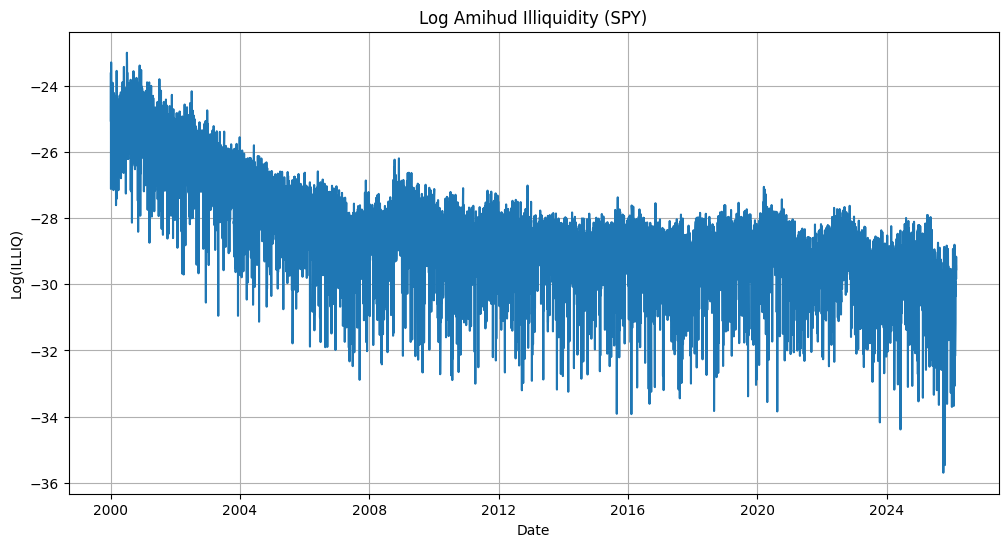

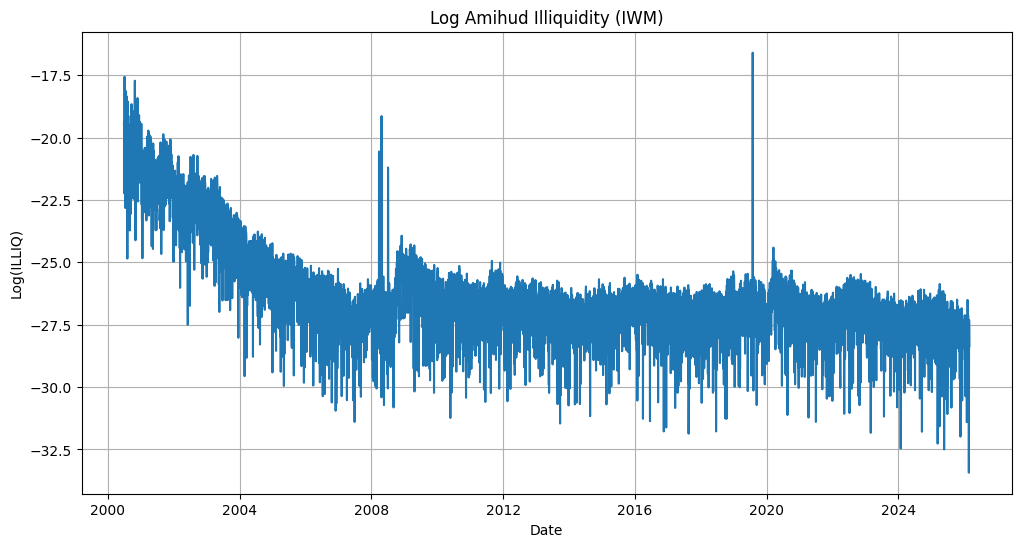

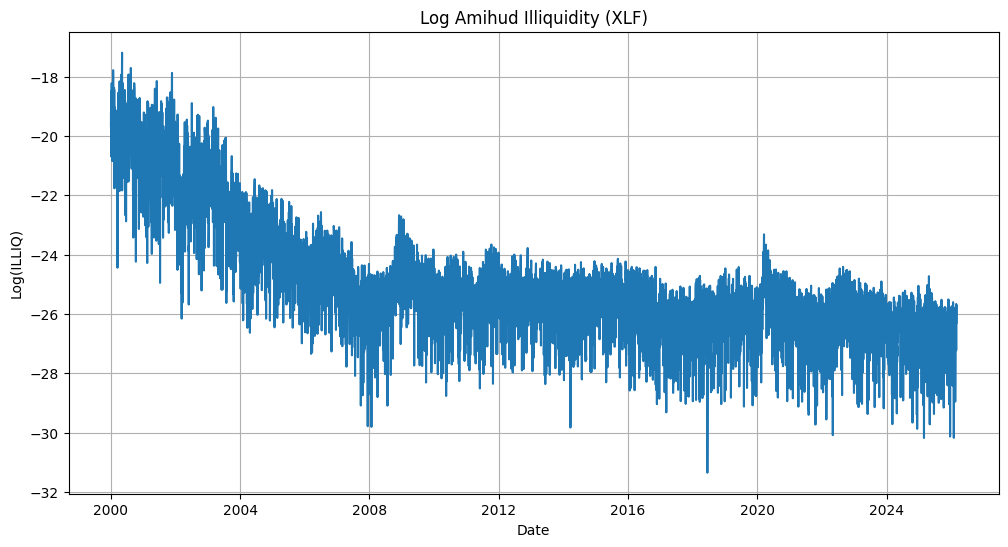

In [5]:
tickers = ["SPY", "IWM", "XLF"]

for ticker in tickers:
    df = build_liquidity_df(ticker)

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["Log_ILLIQ"])
    plt.title(f"Log Amihud Illiquidity ({ticker})")
    plt.xlabel("Date")
    plt.ylabel("Log(ILLIQ)")
    plt.grid(True)
    plt.show()

## Naive Forecast

In [6]:
def walk_forward_naive(series: pd.Series, train_frac: float = 0.7):
    """
    Naive one-step-ahead forecast: yhat_t = y_{t-1}
    Returns actual, preds aligned with the same test window as AR.
    """
    s = series.dropna().copy()
    s_int = pd.Series(s.to_numpy(), index=pd.RangeIndex(len(s)))

    n = len(s_int)
    split = int(n * train_frac)

    # actual values in test window
    actual = s_int.iloc[split:].to_numpy()

    # naive predictions for those points: previous value
    preds = s_int.shift(1).iloc[split:].to_numpy()

    # The first element at split uses value at split-1, so it's defined.
    return actual, preds, split

In [7]:
def eval_forecast(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return rmse, mae

In [8]:
for ticker in tickers:
    df = build_liquidity_df(ticker)['Log_ILLIQ']
    y_true, y_pred, _ = walk_forward_naive(df)
    rmse, mae = eval_forecast(y_true, y_pred)
    print(f'{ticker}   RMSE: {rmse}, MAE: {mae}')

SPY   RMSE: 1.5554232804778836, MAE: 1.1796161733949166
IWM   RMSE: 1.4845127753452958, MAE: 1.0861987282754166
XLF   RMSE: 1.3400277493585044, MAE: 1.0286185822284737


## AR(p)

In [9]:
def walk_forward_ar(series: pd.Series, p: int = 20, train_frac: float = 0.7):
    """
    Walk-forward expanding-window AR(p) one-step-ahead forecasts.
    series: pandas Series with DateTimeIndex (or any index). NaNs allowed (will be dropped).
    Returns: actual, preds, split_index (int)
    """
    s = series.dropna().copy()

    # statsmodels AutoReg behaves best with simple integer index
    s_int = pd.Series(s.to_numpy(), index=pd.RangeIndex(len(s)))

    n = len(s_int)
    split = int(n * train_frac)

    preds = np.empty(n - split)
    actual = s_int.iloc[split:].to_numpy()

    for i, t in enumerate(range(split, n)):
        train = s_int.iloc[:t]
        model = AutoReg(train, lags=p, old_names=False).fit()
        preds[i] = model.forecast(steps=1).iloc[0]

    return actual, preds, split

In [10]:
for ticker in tickers:
    df = build_liquidity_df(ticker)['Log_ILLIQ']
    y_true, y_pred, _ = walk_forward_ar(df)
    rmse, mae = eval_forecast(y_true, y_pred)
    print(f'{ticker}   RMSE: {rmse}, MAE: {mae}')

SPY   RMSE: 1.0903785489871305, MAE: 0.8271158890717317
IWM   RMSE: 1.0575810897948201, MAE: 0.7761434924831934
XLF   RMSE: 0.9713149446438119, MAE: 0.7494485796172582


### AR(p) Summary

Across all three ETFs, AR(20) reduces RMSE by roughly 27–30% relative to the naive benchmark. The improvement is strikingly consistent despite differences in size, volatility, and baseline liquidity levels.

This suggests that liquidity persistence is not asset-specific. Multi-day autoregressive structure appears to be a general property of ETF liquidity dynamics rather than a feature unique to a single asset.

## Multiple Asset Regime Anaysis 

In [11]:
regimes = {
    "Pre_GFC": ("1999-12-03", "2007-12-31"),
    "GFC": ("2008-01-01", "2012-12-31"),
    "Low_Vol_QE": ("2013-01-01", "2019-12-31"),
    "COVID_Tightening": ("2020-01-01", "2024-12-31"),
}

In [12]:
def evaluate_regimes(df, regimes, p=20, train_frac=0.7, col="Log_ILLIQ", min_obs=300):
    results = []

    for regime_name, (start, end) in regimes.items():
        df_reg = df.loc[start:end].copy()

        L = df_reg[col].dropna().copy()
        if len(L) < min_obs:
            continue

        L_int = pd.Series(L.to_numpy(), index=pd.RangeIndex(len(L)))

        n = len(L_int)
        split = int(n * train_frac)

        # ----------------------
        # Naive forecast (on L_int)
        # yhat_t = y_{t-1} for t in test window
        # ----------------------
        actual_naive = L_int.iloc[split:].to_numpy()
        preds_naive = L_int.shift(1).iloc[split:].to_numpy()

        rmse_naive = np.sqrt(mean_squared_error(actual_naive, preds_naive))
        mae_naive  = mean_absolute_error(actual_naive, preds_naive)

        # ----------------------
        # AR(p) using YOUR function
        # ----------------------
        actual_ar, preds_ar, split_ar = walk_forward_ar(L_int, p=p, train_frac=train_frac)

        # sanity: same split
        assert split_ar == split

        rmse_ar = np.sqrt(mean_squared_error(actual_ar, preds_ar))
        mae_ar  = mean_absolute_error(actual_ar, preds_ar)

        # ----------------------
        # Improvement
        # ----------------------
        improvement_rmse = (rmse_naive - rmse_ar) / rmse_naive * 100.0
        improvement_mae  = (mae_naive  - mae_ar)  / mae_naive  * 100.0

        results.append({
            "Regime": regime_name,
            "start": start,
            "end": end,
            "N_obs": n,
            "Naive_RMSE": rmse_naive,
            "AR_RMSE": rmse_ar,
            "RMSE_Improvement_%": improvement_rmse,
            "Naive_MAE": mae_naive,
            "AR_MAE": mae_ar,
            "MAE_Improvement_%": improvement_mae,
            "p": p,
            "train_frac": train_frac
        })

    return pd.DataFrame(results)

In [13]:
spy = build_liquidity_df("SPY")
iwm = build_liquidity_df("IWM")
xlf = build_liquidity_df("XLF")

In [14]:
res_spy = evaluate_regimes(spy, regimes, p=20, train_frac=0.7)
res_spy

,Regime,start,end,N_obs,Naive_RMSE,AR_RMSE,RMSE_Improvement_%,Naive_MAE,AR_MAE,MAE_Improvement_%,p,train_frac
0,Pre_GFC,1999-12-03,2007-12-31,1992,1.525619,1.121923,26.461150,1.183209,0.872539,26.256572,20,0.7
1,GFC,2008-01-01,2012-12-31,1253,1.663667,1.142336,31.336280,1.293225,0.879626,31.981996,20,0.7
2,Low_Vol_QE,2013-01-01,2019-12-31,1748,1.590275,1.115755,29.838886,1.232969,0.863241,29.986801,20,0.7
3,COVID_Tightening,2020-01-01,2024-12-31,1254,1.604918,1.122959,30.030138,1.211463,0.845936,30.172391,20,0.7


In [15]:
res_iwm = evaluate_regimes(iwm, regimes, p=20, train_frac=0.7)
res_iwm

,Regime,start,end,N_obs,Naive_RMSE,AR_RMSE,RMSE_Improvement_%,Naive_MAE,AR_MAE,MAE_Improvement_%,p,train_frac
0,Pre_GFC,1999-12-03,2007-12-31,1869,1.435651,1.038293,27.677875,1.085627,0.777808,28.353981,20,0.7
1,GFC,2008-01-01,2012-12-31,1253,1.409719,0.996559,29.307967,1.073484,0.769643,28.304210,20,0.7
2,Low_Vol_QE,2013-01-01,2019-12-31,1754,1.571225,1.128086,28.203442,1.115412,0.815294,26.906530,20,0.7
3,COVID_Tightening,2020-01-01,2024-12-31,1254,1.382557,0.984574,28.786008,1.032186,0.723757,29.881199,20,0.7


In [16]:
res_xlf = evaluate_regimes(xlf, regimes, p=20, train_frac=0.7)
res_xlf

,Regime,start,end,N_obs,Naive_RMSE,AR_RMSE,RMSE_Improvement_%,Naive_MAE,AR_MAE,MAE_Improvement_%,p,train_frac
0,Pre_GFC,1999-12-03,2007-12-31,1956,1.351266,0.985928,27.036745,1.044880,0.765224,26.764359,20,0.7
1,GFC,2008-01-01,2012-12-31,1212,1.244999,0.911891,26.755683,0.966218,0.711273,26.385852,20,0.7
2,Low_Vol_QE,2013-01-01,2019-12-31,1706,1.351246,1.004699,25.646504,1.039134,0.767730,26.118269,20,0.7
3,COVID_Tightening,2020-01-01,2024-12-31,1236,1.201384,0.896842,25.349266,0.913095,0.677321,25.821420,20,0.7


In [17]:
# visualisation 

In [18]:
# Combine results into one tidy table
def combine_regime_results(res_spy, res_iwm, res_xlf):
    out = []
    for asset, df in [("SPY", res_spy), ("IWM", res_iwm), ("XLF", res_xlf)]:
        tmp = df.copy()
        tmp["Asset"] = asset
        out.append(tmp)
    all_res = pd.concat(out, ignore_index=True)

    regime_order = ["Pre_GFC", "GFC", "Low_Vol_QE", "COVID_Tightening"]
    all_res["Regime"] = pd.Categorical(all_res["Regime"], categories=regime_order, ordered=True)

    return all_res, regime_order

all_res, regime_order = combine_regime_results(res_spy, res_iwm, res_xlf)
all_res.head()

,Regime,start,end,N_obs,Naive_RMSE,AR_RMSE,RMSE_Improvement_%,Naive_MAE,AR_MAE,MAE_Improvement_%,p,train_frac,Asset
0,Pre_GFC,1999-12-03,2007-12-31,1992,1.525619,1.121923,26.461150,1.183209,0.872539,26.256572,20,0.7,SPY
1,GFC,2008-01-01,2012-12-31,1253,1.663667,1.142336,31.336280,1.293225,0.879626,31.981996,20,0.7,SPY
2,Low_Vol_QE,2013-01-01,2019-12-31,1748,1.590275,1.115755,29.838886,1.232969,0.863241,29.986801,20,0.7,SPY
3,COVID_Tightening,2020-01-01,2024-12-31,1254,1.604918,1.122959,30.030138,1.211463,0.845936,30.172391,20,0.7,SPY
4,Pre_GFC,1999-12-03,2007-12-31,1869,1.435651,1.038293,27.677875,1.085627,0.777808,28.353981,20,0.7,IWM


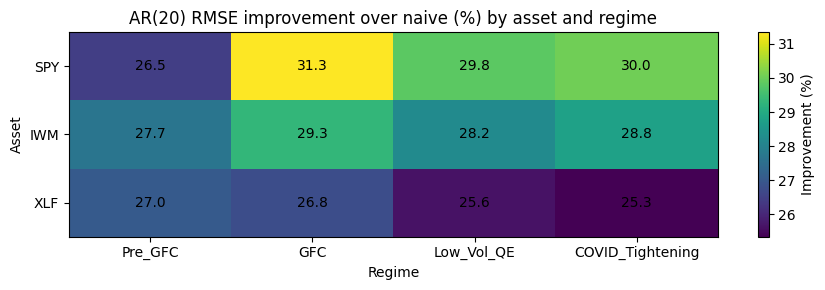

In [19]:
# Pivot to Asset x Regime matrix of improvements
heat = all_res.pivot_table(
    index="Asset", columns="Regime", values="RMSE_Improvement_%", aggfunc="mean"
).reindex(index=["SPY", "IWM", "XLF"], columns=regime_order)

fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(heat.values, aspect="auto")

# ticks/labels
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=0)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

ax.set_title("AR(20) RMSE improvement over naive (%) by asset and regime")
ax.set_xlabel("Regime")
ax.set_ylabel("Asset")

# annotate values
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Improvement (%)")
plt.tight_layout()
plt.show()

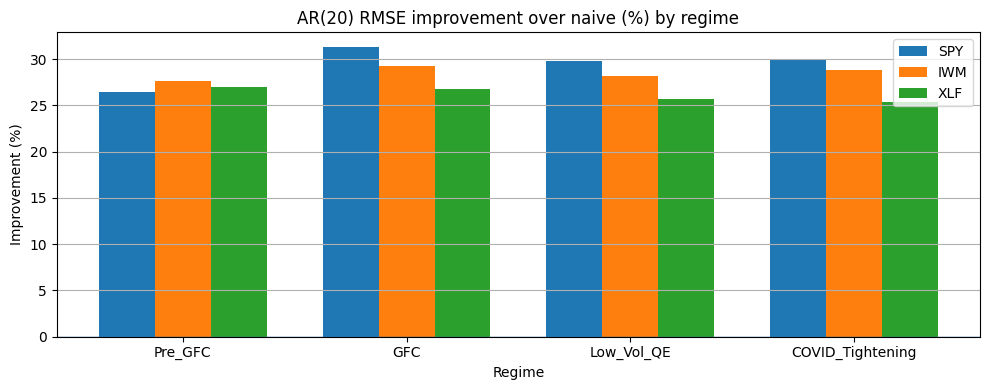

In [20]:
# Prepare values by regime
assets = ["SPY", "IWM", "XLF"]
vals = {
    asset: all_res[all_res["Asset"] == asset]
        .set_index("Regime")
        .reindex(regime_order)["RMSE_Improvement_%"]
        .to_numpy()
    for asset in assets
}

x = np.arange(len(regime_order))
w = 0.25  # bar width

plt.figure(figsize=(10, 4))
plt.bar(x - w, vals["SPY"], width=w, label="SPY")
plt.bar(x,      vals["IWM"], width=w, label="IWM")
plt.bar(x + w,  vals["XLF"], width=w, label="XLF")

plt.xticks(x, regime_order)
plt.axhline(0, linewidth=1)
plt.title("AR(20) RMSE improvement over naive (%) by regime")
plt.xlabel("Regime")
plt.ylabel("Improvement (%)")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.show()

### Cross-Asset Regime Analysis Summary

We evaluate AR(20) performance relative to the naive benchmark across assets (SPY, IWM, XLF) and macro regimes.

Two patterns stand out.

First, AR(20) consistently improves over the naive forecast by roughly 25–31% across all assets and all regimes. There is no regime in which predictability collapses — even during the GFC or COVID tightening periods. Liquidity shocks may increase in magnitude, but the underlying autoregressive structure remains intact.

Second, cross-asset differences are modest. SPY tends to show slightly higher improvements during crisis periods, while XLF is marginally lower overall, but the variation is small. This suggests that liquidity persistence is not driven by a specific sector or capitalization profile.

Taken together, the results indicate that short-horizon liquidity memory is a stable and general market property, robust to both asset type and macroeconomic regime.